In [5]:
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
from qiskit_aer.primitives import Sampler

In [3]:
def groover_circuit(n):
    qc = QuantumCircuit(n)
    qc.h([0, 1])
    qc.cz(0, 1)
    qc.h([0, 1])
    qc.x([0, 1])
    qc.cz(0, 1)
    qc.x([0, 1])
    qc.h([0, 1])
    qc.measure_all()

    return qc

In [4]:
n = 2
qc = groover_circuit(n)
qc.draw()

┌───┐   ┌───┐┌───┐   ┌───┐┌───┐ ░ ┌─┐   
   q_0: ┤ H ├─■─┤ H ├┤ X ├─■─┤ X ├┤ H ├─░─┤M├───
        ├───┤ │ ├───┤├───┤ │ ├───┤├───┤ ░ └╥┘┌─┐
   q_1: ┤ H ├─■─┤ H ├┤ X ├─■─┤ X ├┤ H ├─░──╫─┤M├
        └───┘   └───┘└───┘   └───┘└───┘ ░  ║ └╥┘
meas: 2/═══════════════════════════════════╩══╩═
                                           0  1

In [5]:
sampler = Sampler()
result = sampler.run(qc,shots = 1024).result()
counts = result.quasi_dists[0]

# Number of qubits
n = 2

# Generate full basis
labels = [format(i, f'0{n}b') for i in range(2**n)]

# Fill probabilities (0 if missing)
probs = [counts.get(i, 0) for i in range(2**n)]


print(counts)

{3: 1.0}


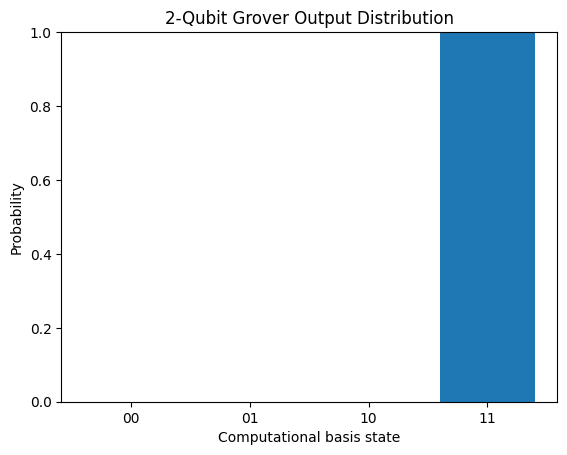

In [6]:
plt.figure()
plt.bar(labels, probs)
plt.xlabel("Computational basis state")
plt.ylabel("Probability")
plt.title("2-Qubit Grover Output Distribution")
plt.ylim(0, 1)
plt.show()


### NOISE MODELLING

In [7]:
from qiskit_aer import AerSimulator
from qiskit_aer.noise import (
    NoiseModel,
    amplitude_damping_error,
    phase_damping_error,
    depolarizing_error,
    ReadoutError
)
from qiskit import transpile


In [8]:
noise_model = NoiseModel()

# ---- Single-qubit errors (T1 / T2 effects) ----
# amp_error = amplitude_damping_error(0.1)   # energy loss
# noise_model.add_all_qubit_quantum_error(amp_error, ['u3'])

# phase_error = phase_damping_error(0.1)     # dephasing
# noise_model.add_all_qubit_quantum_error(phase_error, ['u3'])

# # ---- Two-qubit gate error (entangling gates) ----
# cx_error = depolarizing_error(0.1, 2)
# noise_model.add_all_qubit_quantum_error(cx_error, ['cx'])

# # ---- Readout error (VERY IMPORTANT) ----
# readout_error = ReadoutError([
#     [0.9, 0.1],  # P(measure 0 | prepared 0), P(1|0)
#     [0.1, 0.9]   # P(measure 0 | prepared 1), P(1|1)
# ])
# noise_model.add_all_qubit_readout_error(readout_error)


{'11': 1024}


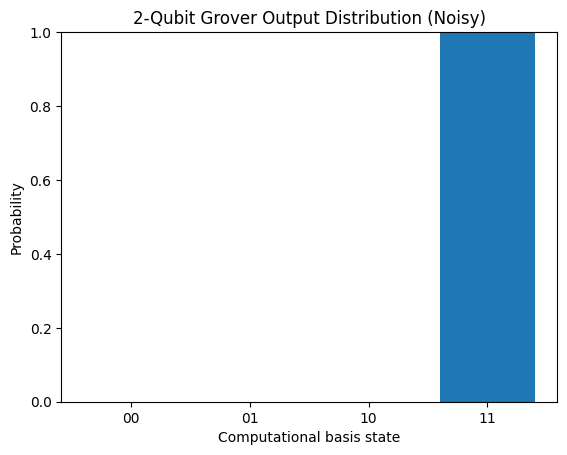

In [9]:
backend = AerSimulator(
    noise_model=noise_model,
)

tqc = transpile(qc, backend)

result_noisy = backend.run(tqc, shots=1024).result()
counts_noisy = result_noisy.get_counts()
print(counts_noisy)

# Correct ordering
labels = ['00', '01', '10', '11']
shots = 1024

probs_noisy = [counts_noisy.get(label, 0) / shots for label in labels]

plt.figure()
plt.bar(labels, probs_noisy)
plt.xlabel("Computational basis state")
plt.ylabel("Probability")
plt.title("2-Qubit Grover Output Distribution (Noisy)")
plt.ylim(0, 1)
plt.show()



### GATE COUNT VS ERROR

In [1]:
def oracle_11_tripled(qc):
    qc.cz(0, 1)
    qc.id(0)
    qc.id(1)

#### this only works because H^2 = I & H^3 = H and idle operations increase noise without affecting the gate operations.

In [2]:
def triple_h(qc, q):
    qc.h(q)
    qc.h(q)
    qc.h(q)

In [3]:
def diffuser_2q_tripled(qc):
    for q in [0, 1]:
        triple_h(qc, q)

    qc.x([0, 1])
    qc.id(0)
    qc.id(1)

    qc.cz(0, 1)
    qc.id(0)
    qc.id(1)

    qc.x([0, 1])

    for q in [0, 1]:
        triple_h(qc, q)

In [8]:
qc_tripled = QuantumCircuit(2,2)

# Tripled initialization
for q in [0, 1]:
    triple_h(qc_tripled, q)

oracle_11_tripled(qc_tripled)
diffuser_2q_tripled(qc_tripled)

qc_tripled.measure([0, 1], [0, 1])
qc_tripled.draw()

┌───┐┌───┐┌───┐   ┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐   ┌───┐┌───┐┌───┐┌───┐»
q_0: ┤ H ├┤ H ├┤ H ├─■─┤ I ├┤ H ├┤ H ├┤ H ├┤ X ├┤ I ├─■─┤ I ├┤ X ├┤ H ├┤ H ├»
     ├───┤├───┤├───┤ │ ├───┤├───┤├───┤├───┤├───┤├───┤ │ ├───┤├───┤├───┤├───┤»
q_1: ┤ H ├┤ H ├┤ H ├─■─┤ I ├┤ H ├┤ H ├┤ H ├┤ X ├┤ I ├─■─┤ I ├┤ X ├┤ H ├┤ H ├»
     └───┘└───┘└───┘   └───┘└───┘└───┘└───┘└───┘└───┘   └───┘└───┘└───┘└───┘»
c: 2/═══════════════════════════════════════════════════════════════════════»
                                                                            »
«     ┌───┐┌─┐   
«q_0: ┤ H ├┤M├───
«     ├───┤└╥┘┌─┐
«q_1: ┤ H ├─╫─┤M├
«     └───┘ ║ └╥┘
«c: 2/══════╩══╩═
«           0  1

In [10]:
sampler_tripled = Sampler()
result_tripled = sampler_tripled.run(qc_tripled,shots = 1024).result()
counts_tripled = result_tripled.quasi_dists[0]

# Number of qubits
n = 2

# Generate full basis
labels = [format(i, f'0{n}b') for i in range(2**n)]

# Fill probabilities (0 if missing)
probs_tripled = [counts_tripled.get(i, 0) for i in range(2**n)]


print(counts_tripled)

{3: 1.0}


#### Now we apply noise to this simulation under 3x gates

In [11]:
from qiskit_aer import AerSimulator
from qiskit_aer.noise import (
    NoiseModel,
    amplitude_damping_error,
    phase_damping_error,
    depolarizing_error,
    ReadoutError
)
from qiskit import transpile

In [20]:
noise_model = NoiseModel()

# ---- Single-qubit errors (T1 / T2 effects) ----
# amp_error = amplitude_damping_error(0.1)   # energy loss
# noise_model.add_all_qubit_quantum_error(amp_error, ['u3'])

# phase_error = phase_damping_error(0.1)     # dephasing
# noise_model.add_all_qubit_quantum_error(phase_error, ['u3'])

# # ---- Two-qubit gate error (entangling gates) ----
# cx_error = depolarizing_error(0.1, 2)
# noise_model.add_all_qubit_quantum_error(cx_error, ['cx'])

# # ---- Readout error (VERY IMPORTANT) ----
readout_error = ReadoutError([
    [0.9, 0.1],  # P(measure 0 | prepared 0), P(1|0)
    [0.1, 0.9]   # P(measure 0 | prepared 1), P(1|1)
])
noise_model.add_all_qubit_readout_error(readout_error)


{'11': 819, '01': 105, '00': 14, '10': 86}


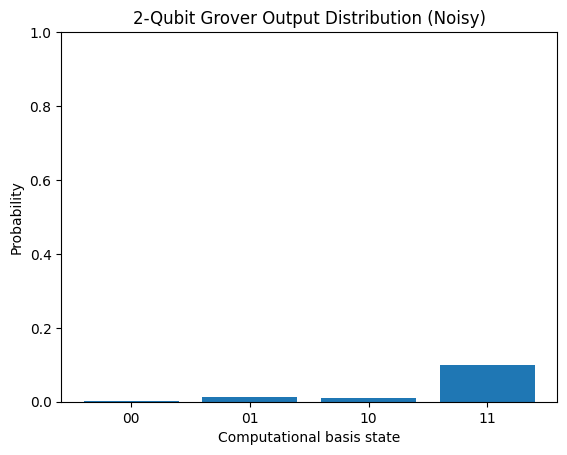

In [21]:
backend = AerSimulator(
    noise_model=noise_model,
)

tqc_tripled = transpile(qc_tripled, backend)

result_noisy_tripled = backend.run(tqc_tripled, shots=1024).result()
counts_noisy_tripled = result_noisy_tripled.get_counts()
print(counts_noisy_tripled)

# Correct ordering
labels = ['00', '01', '10', '11']
shots = 8192

probs_noisy_tripled = [counts_noisy_tripled.get(label, 0) / shots for label in labels]

plt.figure()
plt.bar(labels, probs_noisy_tripled)
plt.xlabel("Computational basis state")
plt.ylabel("Probability")
plt.title("2-Qubit Grover Output Distribution (Noisy)")
plt.ylim(0, 1)
plt.show()